# OTF Scan Pattern — Parallelogram Plan

## Overview

A **parallelogram** scan pattern in galactic coordinates centered at
l=90, b=0 (Cygnus), 15 deg x 9 deg, slanted along the iso-hour-angle
contours.

- **Rising**: parallelogram slanted to follow the HA gradient at 2:30am
- **Setting**: same center, slanted in the opposite direction (HA reverses)

The slant ensures the starting edge is at uniform HA — every track
begins at equal "urgency." The highest-HA corner is observed first.

## Method

1. Compute dHA/dl and dHA/db at (l=90, b=0) at the observation time
2. The iso-HA direction gives the parallelogram slant: delta_l per degree of b
3. For each b-row, shift the l-range by slant * (b - b_center)
4. Start from the highest-HA corner, boustrophedon in b

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
import astropy.coordinates as ac
from astropy.time import Time, TimeDelta

%matplotlib inline
plt.rcParams.update({"figure.dpi": 140, "figure.facecolor": "white"})

# ---------------------------------------------------------------------------
# Fixed parameters
# ---------------------------------------------------------------------------
SCAN_STEP_DEG  = 1.0
DUMPS_PER_BAND = 4
DUMPS_PER_CELL = DUMPS_PER_BAND * 2
HPBW_DEG       = 3.4
NBLOCKS        = 1025
NSAMPLES       = 32768
SAMPLE_RATE    = 2.56e6
MIN_ALT_DEG    = 15.5
AZ_MIN, AZ_MAX = 5.0, 350.0  # match hardware limits

DUMP_CADENCE_S = NBLOCKS * NSAMPLES / SAMPLE_RATE + 1.5
CELL_DWELL_S   = DUMPS_PER_CELL * DUMP_CADENCE_S
SLEW_TIME_S    = 5.0
CELL_TIME_S    = CELL_DWELL_S + SLEW_TIME_S

# Leuschner Observatory
LEO_LAT, LEO_LON, LEO_ALT = 37.9183, -122.1067, 304.0
location = ac.EarthLocation(lat=LEO_LAT * u.deg, lon=LEO_LON * u.deg,
                            height=LEO_ALT * u.m)

T_START = Time("2026-04-16 10:00:00", scale="utc")  # 3:00am PDT

print(f"Start: {T_START.iso} UTC (3:00am PDT)")
print(f"Cell time: {CELL_TIME_S:.0f}s")
print(f"Az limits: [{AZ_MIN}, {AZ_MAX}] (hardware)")

## 1. Compute HA slant and find optimal L_EXTENT

Test L_EXTENT from 10 to 25 with B_EXTENT=9 and find the largest that
keeps ALL cells safe (alt > 15.5, az 5-350) for both rising and setting.

In [ ]:
L_CENTER, B_CENTER = 90.0, 0.0
B_EXTENT = 9

T_RISING  = T_START
T_SETTING = Time("2026-04-16 16:30:00", scale="utc")  # 9:30am PDT

def compute_ha(l_deg, b_deg, obs_time):
    gc = ac.SkyCoord(l=l_deg * u.deg, b=b_deg * u.deg, frame="galactic")
    icrs = gc.transform_to(ac.ICRS())
    lst = obs_time.sidereal_time('apparent', longitude=LEO_LON * u.deg)
    return (lst - icrs.ra).wrap_at(12 * u.hourangle).deg

# Compute iso-HA slant
dl, db = 1.0, 1.0
dha_dl = (compute_ha(L_CENTER + dl, B_CENTER, T_RISING) -
          compute_ha(L_CENTER - dl, B_CENTER, T_RISING)) / (2 * dl)
dha_db = (compute_ha(L_CENTER, B_CENTER + db, T_RISING) -
          compute_ha(L_CENTER, B_CENTER - db, T_RISING)) / (2 * db)
iso_ha_slant = -dha_db / dha_dl

print(f"Iso-HA slant: {iso_ha_slant:.2f} deg l per deg b")
print()


def test_parallelogram(l_center, b_center, l_extent, b_extent, slant, obs_time):
    """Check all cells for alt/az violations. Returns (n_cells, n_bad_alt, n_bad_az, min_alt, max_az)."""
    b_vals = [int(b_center + (i - (b_extent-1)/2)) for i in range(b_extent)]
    n_bad_alt = 0
    n_bad_az = 0
    min_alt = 90.0
    max_az = 0.0
    min_az = 360.0
    n_cells = 0

    t_current = obs_time
    for b_val in b_vals:
        l_shift = round(slant * (b_val - b_center))
        l_row_center = int(l_center) + l_shift
        for j in range(l_extent):
            l_val = l_row_center + j - (l_extent - 1) // 2
            t_mid = t_current + TimeDelta(CELL_DWELL_S / 2, format="sec")

            gc = ac.SkyCoord(l=l_val * u.deg, b=b_val * u.deg, frame="galactic")
            altaz = gc.transform_to(ac.AltAz(obstime=t_mid, location=location))
            alt, az = altaz.alt.deg, altaz.az.deg

            if alt < MIN_ALT_DEG:
                n_bad_alt += 1
            if az < AZ_MIN or az > AZ_MAX:
                n_bad_az += 1
            min_alt = min(min_alt, alt)
            max_az = max(max_az, az)
            min_az = min(min_az, az)
            n_cells += 1
            t_current += TimeDelta(CELL_TIME_S, format="sec")

    return n_cells, n_bad_alt, n_bad_az, min_alt, min_az, max_az


# Scan L_EXTENT from 10 to 25
print(f"{'L_EXT':>5} {'cells':>5} {'rise_bad':>8} {'set_bad':>7} "
      f"{'rise_alt':>8} {'rise_az':>12} {'set_alt':>7} {'set_az':>12} {'time_h':>6}")
print("-" * 85)

best_l_extent = 0
for l_ext in range(10, 26):
    r_n, r_ba, r_bz, r_malt, r_mnaz, r_mxaz = test_parallelogram(
        L_CENTER, B_CENTER, l_ext, B_EXTENT, iso_ha_slant, T_RISING)
    s_n, s_ba, s_bz, s_malt, s_mnaz, s_mxaz = test_parallelogram(
        L_CENTER, B_CENTER, l_ext, B_EXTENT, -iso_ha_slant, T_SETTING)

    r_bad = r_ba + r_bz
    s_bad = s_ba + s_bz
    time_h = r_n * CELL_TIME_S / 3600

    marker = " <-- SAFE" if r_bad == 0 and s_bad == 0 else ""
    if r_bad == 0 and s_bad == 0:
        best_l_extent = l_ext

    print(f"{l_ext:>5} {r_n:>5} {r_bad:>8} {s_bad:>7} "
          f"{r_malt:>8.1f} {r_mnaz:>5.1f}-{r_mxaz:<5.1f} "
          f"{s_malt:>7.1f} {s_mnaz:>5.1f}-{s_mxaz:<5.1f} "
          f"{time_h:>6.1f}{marker}")

print()
print(f"Best L_EXTENT with zero violations: {best_l_extent}")
print(f"  Cells: {best_l_extent * B_EXTENT}")
print(f"  Time: {best_l_extent * B_EXTENT * CELL_TIME_S / 3600:.1f} h per pass")

L_EXTENT = best_l_extent
rising_slant = iso_ha_slant
setting_slant = -iso_ha_slant

## 2. Build parallelogram grids and simulate observations

In [3]:
def build_parallelogram(l_center, b_center, l_extent, b_extent, slant, step=1.0):
    """Build a parallelogram grid in whole-degree galactic coordinates.
    
    For each b-row, the l-range is shifted by round(slant * (b - b_center))
    so all pointings land on integer (l, b).
    """
    b_vals = np.arange(b_center - (b_extent-1)/2, b_center + (b_extent-1)/2 + 0.1, step)
    all_cells = {}
    
    for row_idx, b_val in enumerate(b_vals):
        l_shift = round(slant * (b_val - b_center))  # integer shift
        l_row_center = l_center + l_shift
        l_vals = np.arange(l_row_center - (l_extent-1)/2, 
                           l_row_center + (l_extent-1)/2 + 0.1, step)
        for col_idx, l_val in enumerate(l_vals):
            all_cells[(row_idx, col_idx)] = (int(l_val), int(b_val))
    
    return all_cells, b_vals


def build_parallelogram_boustrophedon(cells_dict, b_vals, n_l, start_high_ha_l=True):
    """Order parallelogram cells as boustrophedon along l, stepping in b."""
    ordered = []
    for i in range(len(b_vals)):
        row_cells = [cells_dict[(i, j)] for j in range(n_l)]
        if (i % 2 == 0) != start_high_ha_l:
            row_cells = list(reversed(row_cells))
        ordered.extend(row_cells)
    return ordered


def simulate_pass(cell_list, start_time, label):
    t_current = start_time
    data = []
    for idx, (cell_l, cell_b) in enumerate(cell_list):
        t_mid = t_current + TimeDelta(CELL_DWELL_S / 2, format="sec")
        gc = ac.SkyCoord(l=cell_l * u.deg, b=cell_b * u.deg, frame="galactic")
        icrs = gc.transform_to(ac.ICRS())
        altaz = gc.transform_to(ac.AltAz(obstime=t_mid, location=location))
        data.append({
            'cell_idx': idx, 'gal_l': cell_l, 'gal_b': cell_b,
            'alt': altaz.alt.deg, 'az': altaz.az.deg,
            'ra': icrs.ra.deg, 'dec': icrs.dec.deg,
            'time': t_mid, 'pass': label,
        })
        t_current += TimeDelta(CELL_TIME_S, format="sec")
    return data, t_current


# ---- Rising parallelogram ----
rising_cells_dict, rising_b_vals = build_parallelogram(
    L_CENTER, B_CENTER, L_EXTENT, B_EXTENT, rising_slant)
rising_cell_list = build_parallelogram_boustrophedon(
    rising_cells_dict, rising_b_vals, L_EXTENT, start_high_ha_l=True)
grid_rising, rising_end = simulate_pass(rising_cell_list, T_RISING, 'rising')

# ---- Setting parallelogram (opposite slant) ----
setting_cells_dict, setting_b_vals = build_parallelogram(
    L_CENTER, B_CENTER, L_EXTENT, B_EXTENT, setting_slant)
setting_cell_list = build_parallelogram_boustrophedon(
    setting_cells_dict, setting_b_vals, L_EXTENT, start_high_ha_l=True)
grid_setting, setting_end = simulate_pass(setting_cell_list, T_SETTING, 'setting')

# Print grid shapes
print("Rising parallelogram (whole-degree pointings):")
for i, b_val in enumerate(rising_b_vals):
    row = [rising_cells_dict[(i, j)] for j in range(L_EXTENT)]
    print(f"  b={int(b_val):+d}: l=[{row[0][0]}, {row[-1][0]}]")
print()
print("Setting parallelogram:")
for i, b_val in enumerate(setting_b_vals):
    row = [setting_cells_dict[(i, j)] for j in range(L_EXTENT)]
    print(f"  b={int(b_val):+d}: l=[{row[0][0]}, {row[-1][0]}]")
print()

for label, gd, t_start, t_end in [
    ('Rising', grid_rising, T_RISING, rising_end),
    ('Setting', grid_setting, T_SETTING, setting_end),
]:
    dur = (t_end - t_start).sec / 3600
    alts = [g['alt'] for g in gd]
    azs = [g['az'] for g in gd]
    print(f"{label}: {len(gd)} cells, {dur:.1f} h")
    print(f"  Alt: {min(alts):.1f} - {max(alts):.1f}")
    print(f"  Az:  {min(azs):.1f} - {max(azs):.1f}")
    n_bad_alt = sum(a < MIN_ALT_DEG for a in alts)
    n_bad_az = sum(a < AZ_MIN or a > AZ_MAX for a in azs)
    if n_bad_alt: print(f"  WARNING: {n_bad_alt} cells below {MIN_ALT_DEG} deg!")
    if n_bad_az: print(f"  WARNING: {n_bad_az} cells outside az [{AZ_MIN}, {AZ_MAX}]!")
    print()

Rising parallelogram (whole-degree pointings):
  b=-4: l=[78, 94]
  b=-3: l=[79, 95]
  b=-2: l=[80, 96]
  b=-1: l=[81, 97]
  b=+0: l=[82, 98]
  b=+1: l=[83, 99]
  b=+2: l=[84, 100]
  b=+3: l=[85, 101]
  b=+4: l=[86, 102]

Setting parallelogram:
  b=-4: l=[86, 102]
  b=-3: l=[85, 101]
  b=-2: l=[84, 100]
  b=-1: l=[83, 99]
  b=+0: l=[82, 98]
  b=+1: l=[81, 97]
  b=+2: l=[80, 96]
  b=+3: l=[79, 95]
  b=+4: l=[78, 94]

Rising: 153 cells, 5.2 h
  Alt: 29.2 - 79.3
  Az:  22.4 - 70.7

Setting: 153 cells, 5.2 h
  Alt: 19.9 - 79.7
  Az:  291.2 - 356.1



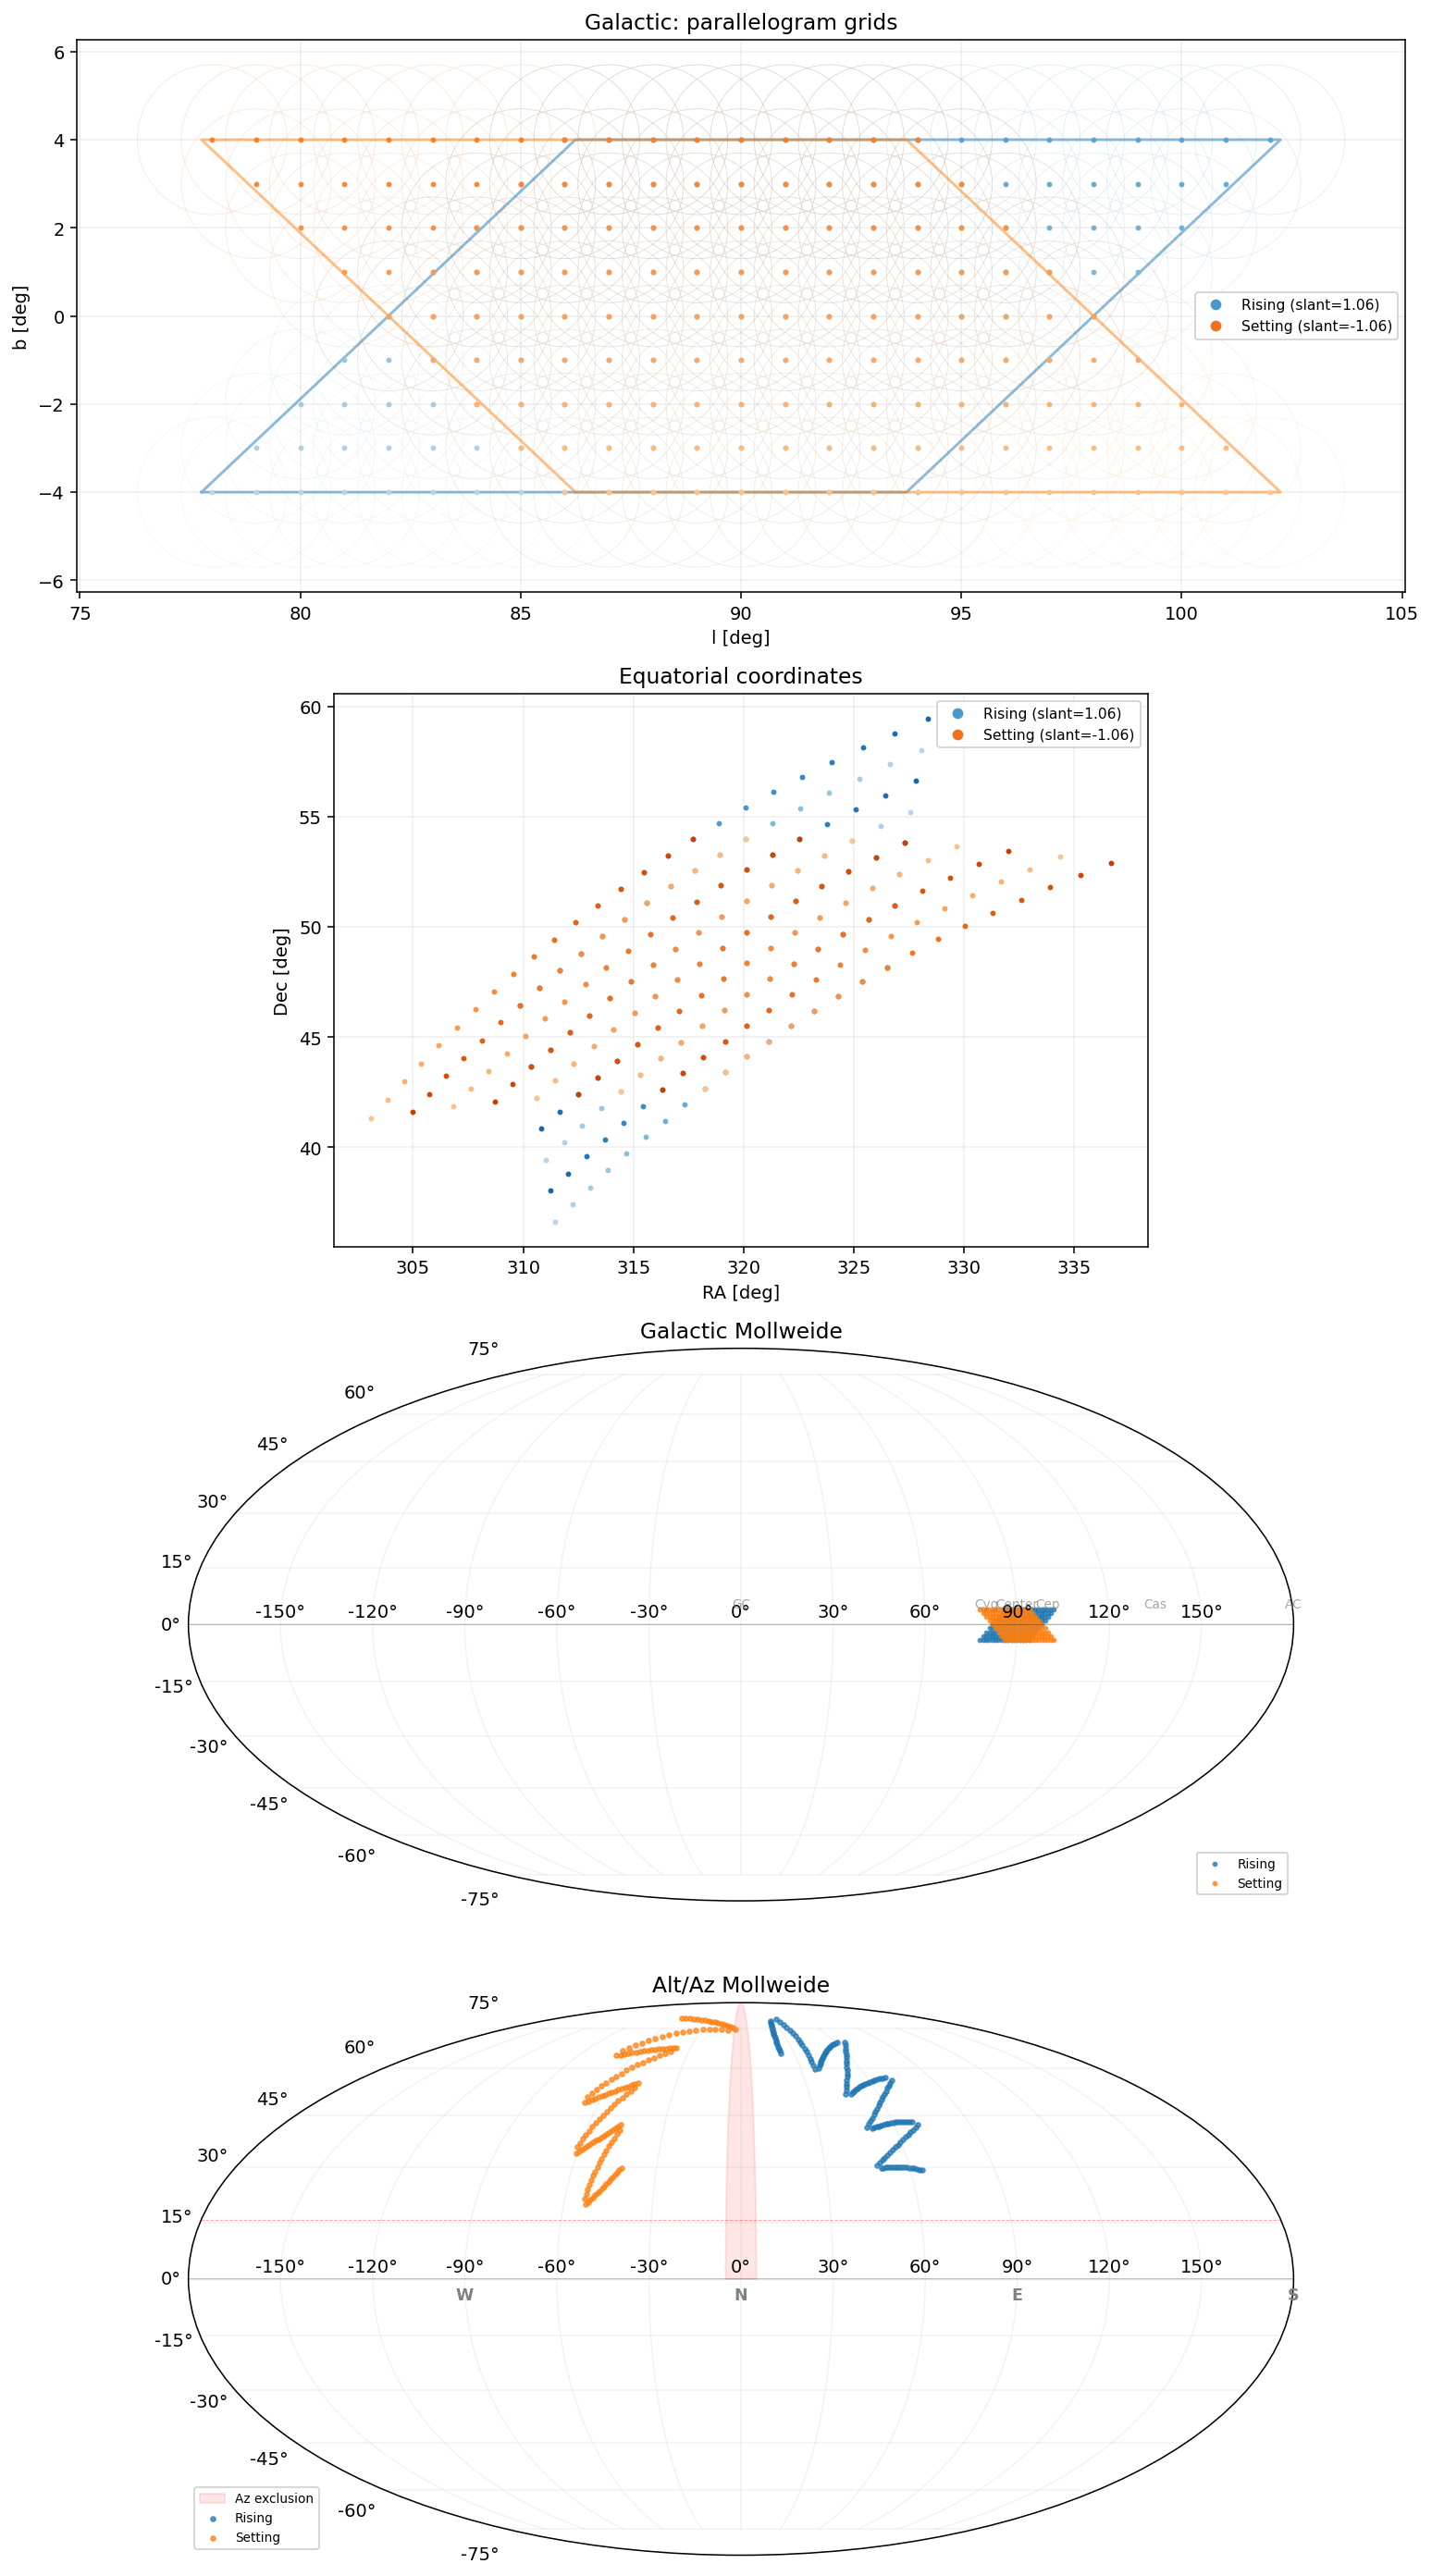

Total coverage: l=[78.0, 102.0], b=[-4.0, 4.0]
Rising: 153 cells (5.2h)
Setting: 153 cells (5.2h)


In [4]:
# ---- 3. Plots: galactic, equatorial, galactic Mollweide, alt/az Mollweide ----

fig = plt.figure(figsize=(16, 20))

pass_configs = [
    ('rising', grid_rising, plt.cm.Blues, 'Rising (slant={:.2f})'.format(rising_slant)),
    ('setting', grid_setting, plt.cm.Oranges, 'Setting (slant={:.2f})'.format(setting_slant)),
]

n_colors = max(B_EXTENT, L_EXTENT)

# --- (a) Galactic ---
ax = fig.add_subplot(4, 1, 1)
for plab, gd, cmap, pname in pass_configs:
    colors = cmap(np.linspace(0.3, 0.8, n_colors))
    for g in gd:
        # Color by b-row index
        b_idx = int(round(g['gal_b'] - (B_CENTER - (B_EXTENT-1)/2))) % n_colors
        c = colors[b_idx]
        beam = Circle((g['gal_l'], g['gal_b']), HPBW_DEG/2,
                       fill=False, edgecolor=c, alpha=0.2, lw=0.4)
        ax.add_patch(beam)
        ax.plot(g['gal_l'], g['gal_b'], 'o', color=c, ms=2, zorder=5)
    ax.plot([], [], 'o', color=cmap(0.6), ms=5, label=pname)

# Draw parallelogram outlines
for cells_dict, b_vals, slant, color in [
    (rising_cells_dict, rising_b_vals, rising_slant, 'C0'),
    (setting_cells_dict, setting_b_vals, setting_slant, 'C1'),
]:
    # Four corners of the parallelogram
    b_lo, b_hi = b_vals[0], b_vals[-1]
    l_shift_lo = slant * (b_lo - B_CENTER)
    l_shift_hi = slant * (b_hi - B_CENTER)
    corners_l = [L_CENTER + l_shift_lo - (L_EXTENT-1)/2,
                 L_CENTER + l_shift_lo + (L_EXTENT-1)/2,
                 L_CENTER + l_shift_hi + (L_EXTENT-1)/2,
                 L_CENTER + l_shift_hi - (L_EXTENT-1)/2,
                 L_CENTER + l_shift_lo - (L_EXTENT-1)/2]
    corners_b = [b_lo, b_lo, b_hi, b_hi, b_lo]
    ax.plot(corners_l, corners_b, '-', color=color, lw=1.5, alpha=0.5)

ax.set_xlabel("l [deg]"); ax.set_ylabel("b [deg]")
ax.set_title("Galactic: parallelogram grids"); ax.set_aspect("equal")
ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

# --- (b) Equatorial ---
ax = fig.add_subplot(4, 1, 2)
for plab, gd, cmap, pname in pass_configs:
    colors = cmap(np.linspace(0.3, 0.8, n_colors))
    for g in gd:
        c = colors[g['cell_idx'] % n_colors]
        ax.plot(g['ra'], g['dec'], 'o', color=c, ms=2, zorder=5)
    ax.plot([], [], 'o', color=cmap(0.6), ms=5, label=pname)
ax.set_xlabel("RA [deg]"); ax.set_ylabel("Dec [deg]")
ax.set_title("Equatorial coordinates"); ax.set_aspect("equal")
ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

# --- (c) Galactic Mollweide ---
ax = fig.add_subplot(4, 1, 3, projection='mollweide')
l_plane = np.linspace(-np.pi, np.pi, 500)
ax.plot(l_plane, np.zeros_like(l_plane), 'k-', lw=0.5, alpha=0.3)
ax.grid(True, alpha=0.15)
for gd, color, label in [(grid_rising, 'C0', 'Rising'), (grid_setting, 'C1', 'Setting')]:
    gl = np.array([g['gal_l'] if g['gal_l'] <= 180 else g['gal_l']-360 for g in gd])
    gb = np.array([g['gal_b'] for g in gd])
    ax.scatter(np.deg2rad(gl), np.deg2rad(gb), s=4, color=color, alpha=0.7, label=label)
for ld, name in [(0,"GC"),(80,"Cyg"),(90,"Center"),(100,"Cep"),(135,"Cas"),(180,"AC")]:
    lr = np.deg2rad(ld if ld <= 180 else ld-360)
    ax.annotate(name, (lr, 0), fontsize=7, ha='center', va='bottom',
                color='gray', alpha=0.7, xytext=(0,8), textcoords='offset points')
ax.set_title("Galactic Mollweide"); ax.legend(fontsize=7, loc='lower right')

# --- (d) Alt/Az Mollweide ---
ax = fig.add_subplot(4, 1, 4, projection='mollweide')
az_line = np.linspace(-np.pi, np.pi, 500)
ax.plot(az_line, np.zeros_like(az_line), 'k-', lw=0.5, alpha=0.3)
ax.fill(np.deg2rad([-5,5,5,-5,-5]), np.deg2rad([0,0,90,90,0]),
        color='red', alpha=0.1, label='Az exclusion')
ax.plot(az_line, np.full_like(az_line, np.deg2rad(15.5)), 'r--', lw=0.5, alpha=0.4)
ax.grid(True, alpha=0.15)
for gd, color, label in [(grid_rising, 'C0', 'Rising'), (grid_setting, 'C1', 'Setting')]:
    az = np.array([g['az'] for g in gd]); az[az>180] -= 360
    alt = np.array([g['alt'] for g in gd])
    ax.scatter(np.deg2rad(az), np.deg2rad(alt), s=6, color=color, alpha=0.7, label=label)
for azd, name in [(0,"N"),(90,"E"),(180,"S"),(-90,"W")]:
    ax.annotate(name, (np.deg2rad(azd), np.deg2rad(-2)), fontsize=9,
                ha='center', va='top', fontweight='bold', color='gray')
ax.set_title("Alt/Az Mollweide"); ax.legend(fontsize=7, loc='lower left')

fig.tight_layout()
plt.show()

# Summary
all_l = [g['gal_l'] for g in grid_rising + grid_setting]
all_b = [g['gal_b'] for g in grid_rising + grid_setting]
print(f"Total coverage: l=[{min(all_l):.1f}, {max(all_l):.1f}], b=[{min(all_b):.1f}, {max(all_b):.1f}]")
print(f"Rising: {len(grid_rising)} cells ({(rising_end - T_RISING).sec/3600:.1f}h)")
print(f"Setting: {len(grid_setting)} cells ({(setting_end - T_SETTING).sec/3600:.1f}h)")